# Robot Dynamics Identification Pipeline — Results Visualization

本 Notebook 读取 `datasets/visualization/latest_results.json`，展示最近一次 `run_pipeline.py` 的结果。

使用方式：
1. 先运行 `python run_pipeline.py` 生成最新结果。
2. 在本 Notebook 中点击 `Run All`。
3. 如果只想预览，不保存图片，保持 `save_figures=False`。


In [ ]:
from plot_results_support import load_plot_context

globals().update(load_plot_context(save_figures=False))

print('=' * 72)
print('当前可视化结果摘要')
print('=' * 72)
print(f'结果时间: {GENERATED_AT}')
print(f'运行时间戳: {RUN_TIMESTAMP}')
print(f'结果前缀: {RESULT_STEM}')
print(f'机器人模型: {ROBOT_NAME}')
print(f'数据来源: {DATA_SOURCE}')
print(f'结果文件: {VIS_FILE}')
print(f'关节数量: {N_JOINTS}')
print(f'图片保存: {SAVE_FIGURES}  (False=只显示不保存, True=保存到 {FIGURE_DIR})')
print(f"Identification test RMSE: {payload['identification']['test']['global_rmse']:.6f} N·m")
print(f"Linear test RMSE:         {payload['linear']['test']['global_rmse']:.6f} N·m")
print(f"MLP test RMSE:            {payload['mlp']['test']['global_rmse']:.6f} N·m")
print(f"Linear improvement:       {payload['linear']['test']['improvement_percent']:.2f}%")
print(f"MLP improvement:          {payload['mlp']['test']['improvement_percent']:.2f}%")


当前可视化结果摘要
结果时间: 2026-04-24T16:37:54
运行时间戳: 20260424_162805
结果前缀: real_sensed_20260424_162805
机器人模型: 05_urdf
数据来源: real
结果文件: datasets/visualization/latest_results.json
关节数量: 7
图片保存: False  (False=只显示不保存, True=保存到 /home/xpm/projects/dynamic7dof/dynamic_regress/datasets/visualization/figures)
Identification test RMSE: 1.586726 N·m
Linear test RMSE:         0.758566 N·m
MLP test RMSE:            0.376377 N·m
Linear improvement:       45.78%
MLP improvement:          73.03%


---
## Fig 1 — 流程各阶段全局误差（RMSE / MAE）


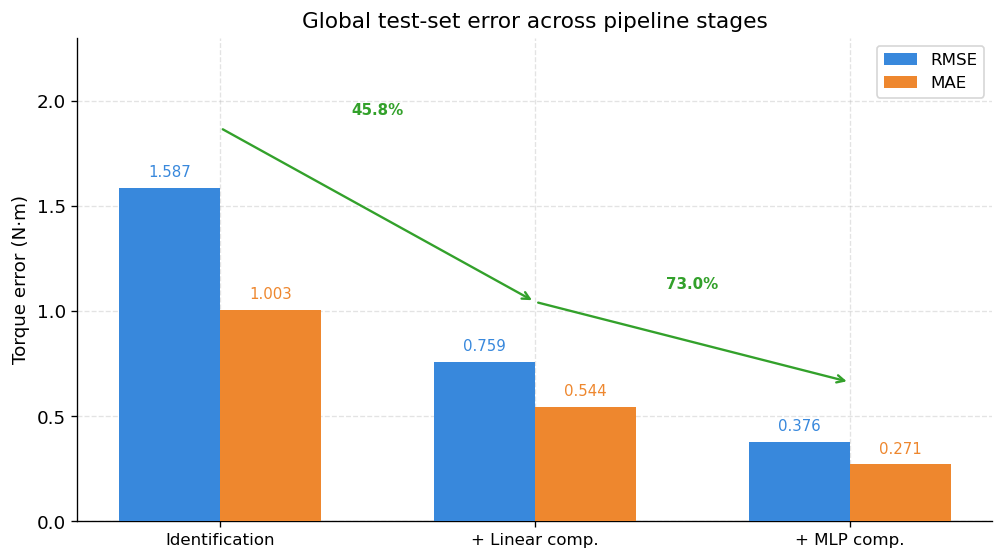

In [2]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))

x = np.arange(len(STAGES))
w = 0.32

bars1 = ax.bar(x - w/2, rmse_global, w, color=C_BLUE, label='RMSE', zorder=3)
bars2 = ax.bar(x + w/2, mae_global, w, color=C_ORANGE, label='MAE', zorder=3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(rmse_global) * 0.025,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, color=C_BLUE)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(rmse_global) * 0.025,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, color=C_ORANGE)

for i, pct in enumerate(global_improvements):
    if i + 1 >= len(rmse_global):
        continue
    y0 = rmse_global[i] + max(rmse_global) * 0.18
    y1 = rmse_global[i + 1] + max(rmse_global) * 0.18
    ax.annotate('', xy=(i + 1, y1), xytext=(i, y0),
                arrowprops=dict(arrowstyle='->', color=C_GREEN, lw=1.4))
    ax.text(i + 0.5, max(y0, y1) + max(rmse_global) * 0.04, f'{pct:.1f}%',
            ha='center', fontsize=9, color=C_GREEN, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(STAGES, fontsize=10)
ax.set_ylabel('Torque error (N·m)')
ax.set_ylim(0, max(rmse_global.max(), mae_global.max()) * 1.45)
ax.set_title('Global test-set error across pipeline stages', fontsize=13, fontweight='normal')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('fig1_pipeline_overview.png', dpi=150)
plt.show()


---
## Fig 2 — 每关节 RMSE：三阶段对比


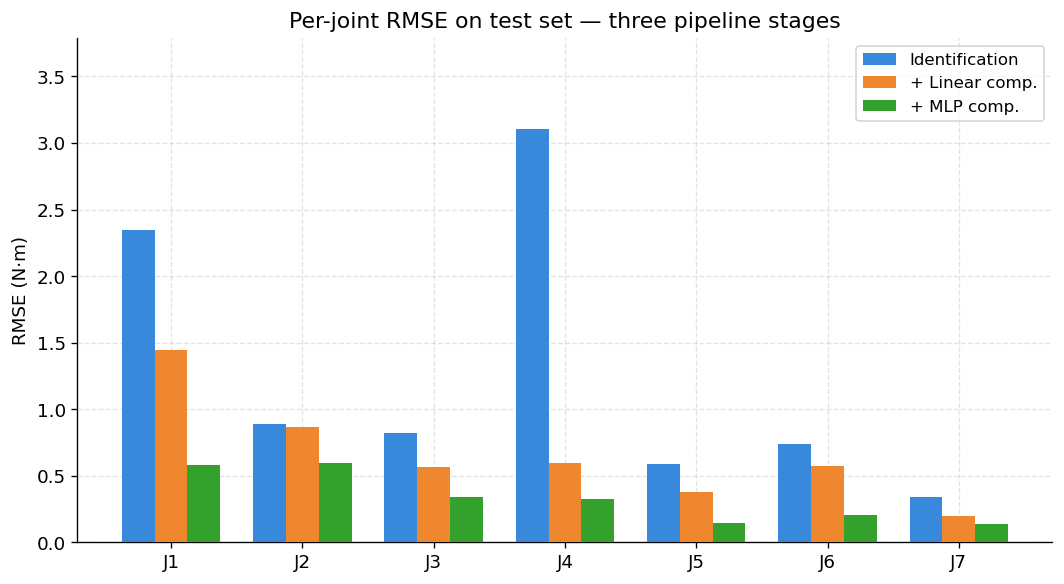

In [3]:
fig, ax = plt.subplots(figsize=(max(9, N_JOINTS * 1.2), 5))

x, w = np.arange(N_JOINTS), 0.25
ax.bar(x - w, rmse_ident, w, color=C_BLUE, label='Identification', zorder=3)
ax.bar(x, rmse_linear, w, color=C_ORANGE, label='+ Linear comp.', zorder=3)
ax.bar(x + w, rmse_mlp, w, color=C_GREEN, label='+ MLP comp.', zorder=3)

ax.set_xticks(x)
ax.set_xticklabels(JOINTS)
ax.set_ylabel('RMSE (N·m)')
ax.set_ylim(0, max(rmse_ident.max(), rmse_linear.max(), rmse_mlp.max()) * 1.22)
ax.set_title('Per-joint RMSE on test set — three pipeline stages', fontweight='normal')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('fig2_per_joint_rmse.png', dpi=150)
plt.show()


---
## Fig 3 — 每关节 MAE：三阶段对比


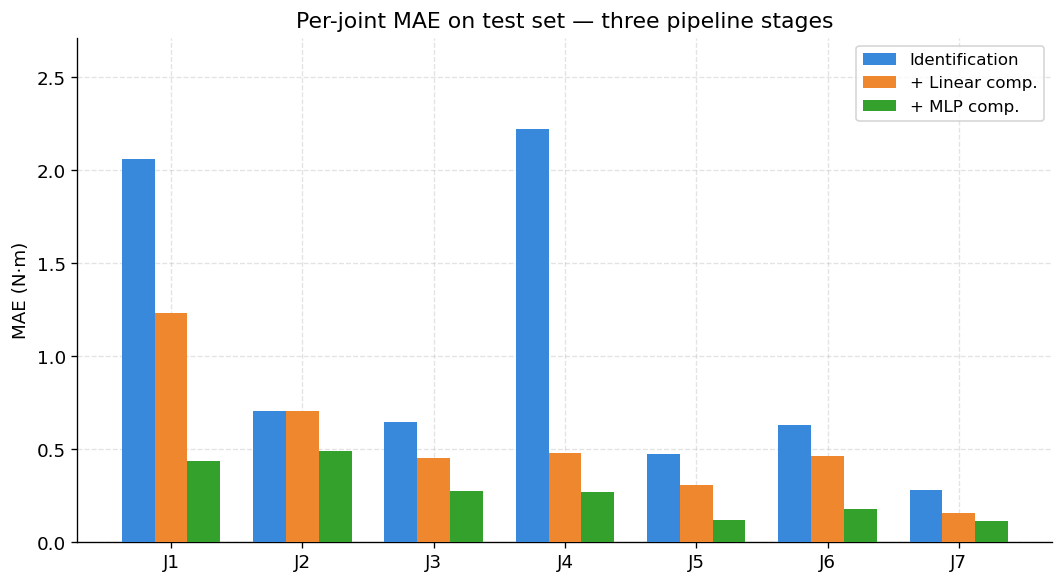

In [4]:
fig, ax = plt.subplots(figsize=(max(9, N_JOINTS * 1.2), 5))

x, w = np.arange(N_JOINTS), 0.25
ax.bar(x - w, mae_ident, w, color=C_BLUE, label='Identification', zorder=3)
ax.bar(x, mae_linear, w, color=C_ORANGE, label='+ Linear comp.', zorder=3)
ax.bar(x + w, mae_mlp, w, color=C_GREEN, label='+ MLP comp.', zorder=3)

ax.set_xticks(x)
ax.set_xticklabels(JOINTS)
ax.set_ylabel('MAE (N·m)')
ax.set_ylim(0, max(mae_ident.max(), mae_linear.max(), mae_mlp.max()) * 1.22)
ax.set_title('Per-joint MAE on test set — three pipeline stages', fontweight='normal')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('fig3_per_joint_mae.png', dpi=150)
plt.show()


---
## Fig 4 — 每关节改善率（%）：线性 vs MLP


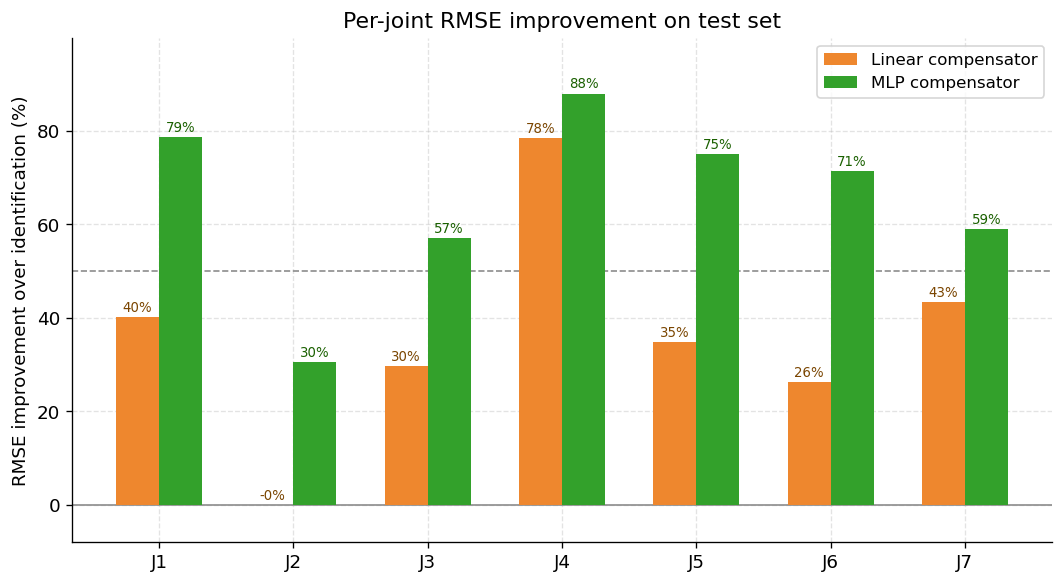

In [5]:
fig, ax = plt.subplots(figsize=(max(9, N_JOINTS * 1.2), 5))

x, w = np.arange(N_JOINTS), 0.32
ax.bar(x - w/2, impr_linear, w, color=C_ORANGE, label='Linear compensator', zorder=3)
ax.bar(x + w/2, impr_mlp, w, color=C_GREEN, label='MLP compensator', zorder=3)
ax.axhline(0, color=C_GRAY, linewidth=1, zorder=2)
ax.axhline(50, color=C_GRAY, linestyle='--', linewidth=1, zorder=2)

for i in range(N_JOINTS):
    ax.text(i - w/2, impr_linear[i] + 1.2, f'{impr_linear[i]:.0f}%',
            ha='center', fontsize=8, color='#7A4500')
    ax.text(i + w/2, impr_mlp[i] + 1.2, f'{impr_mlp[i]:.0f}%',
            ha='center', fontsize=8, color='#1A6000')

ax.set_xticks(x)
ax.set_xticklabels(JOINTS)
ax.set_ylabel('RMSE improvement over identification (%)')
y_min = min(0, impr_linear.min(), impr_mlp.min()) - 8
y_max = max(55, impr_linear.max(), impr_mlp.max()) + 12
ax.set_ylim(y_min, y_max)
ax.set_title('Per-joint RMSE improvement on test set', fontweight='normal')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('fig4_per_joint_improvement.png', dpi=150)
plt.show()


---
## Fig 5 — 多随机种子稳定性：Train / Val / Test RMSE


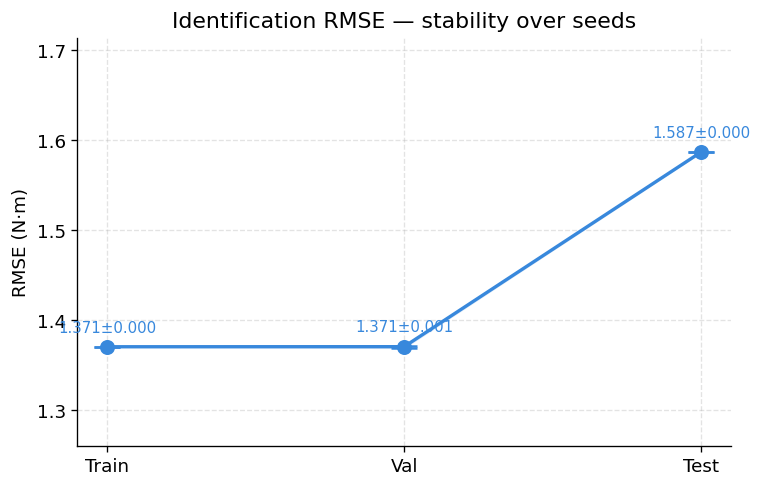

In [6]:
fig, ax = plt.subplots(figsize=(6.5, 4.2))

splits = ['Train', 'Val', 'Test']
rmse_mean = stability_rmse_mean
rmse_std = stability_rmse_std
x = np.arange(len(splits))

ax.errorbar(x, rmse_mean, yerr=rmse_std,
            fmt='o-', color=C_BLUE, markerfacecolor=C_BLUE,
            linewidth=2, markersize=8, capsize=8, capthick=1.5, zorder=3)
ax.fill_between(x, rmse_mean - rmse_std, rmse_mean + rmse_std, alpha=0.15, color=C_BLUE)

for i, (m, s) in enumerate(zip(rmse_mean, rmse_std)):
    ax.text(i, m + s + max(rmse_mean) * 0.01, f'{m:.3f}±{s:.3f}',
            ha='center', fontsize=9, color=C_BLUE)

ax.set_xticks(x)
ax.set_xticklabels(splits)
ax.set_ylabel('RMSE (N·m)')
y_low = max(0, (rmse_mean - rmse_std).min() * 0.92)
y_high = (rmse_mean + rmse_std).max() * 1.08
if y_high <= y_low:
    y_high = y_low + 1.0
ax.set_ylim(y_low, y_high)
ax.set_title('Identification RMSE — stability over seeds', fontweight='normal')

plt.tight_layout()
plt.savefig('fig5_stability.png', dpi=150)
plt.show()


---
## Fig 6 — RMSE 热力图（关节 × 流程阶段）


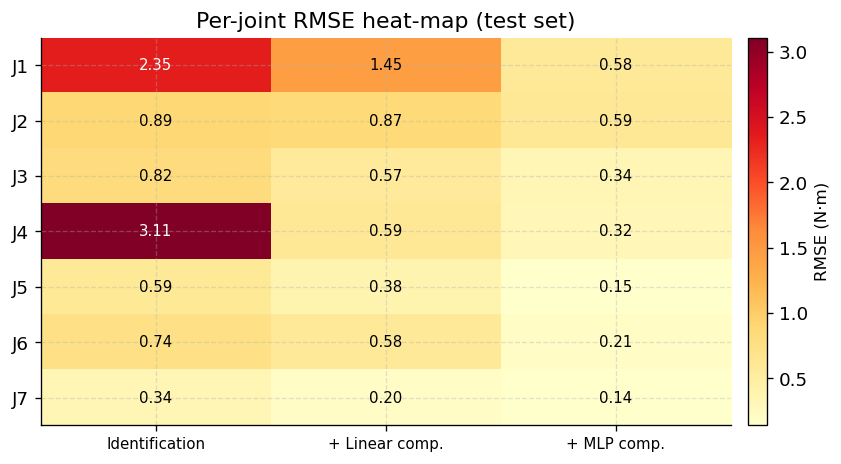

In [7]:
fig, ax = plt.subplots(figsize=(7.5, max(4, N_JOINTS * 0.55)))

heatmap = np.vstack([rmse_ident, rmse_linear, rmse_mlp]).T
im = ax.imshow(heatmap, cmap='YlOrRd', aspect='auto')
cbar = fig.colorbar(im, ax=ax, pad=0.02)
cbar.set_label('RMSE (N·m)', fontsize=10)

ax.set_xticks(range(len(STAGES)))
ax.set_xticklabels(STAGES, fontsize=9)
ax.set_yticks(range(N_JOINTS))
ax.set_yticklabels(JOINTS)
ax.set_title('Per-joint RMSE heat-map (test set)', fontweight='normal')

threshold = heatmap.max() * 0.55
for r in range(N_JOINTS):
    for c in range(len(STAGES)):
        val = heatmap[r, c]
        color = 'white' if val > threshold else 'black'
        ax.text(c, r, f'{val:.2f}', ha='center', va='center', fontsize=9, color=color)

plt.tight_layout()
plt.savefig('fig6_heatmap.png', dpi=150)
plt.show()


---
## Fig 7 — 每关节 RMSE 折线轮廓


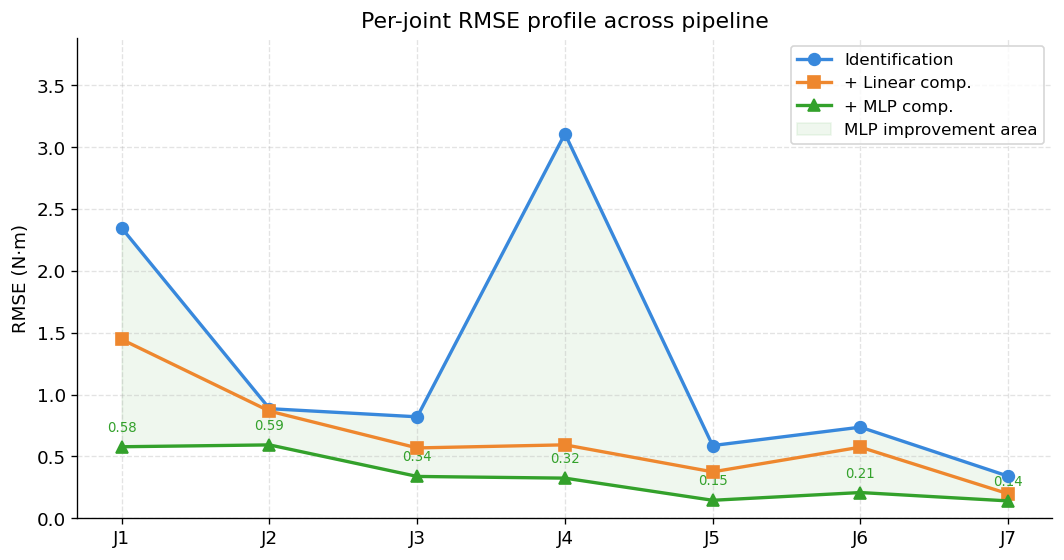

In [8]:
fig, ax = plt.subplots(figsize=(max(9, N_JOINTS * 1.2), 4.8))

xax = np.arange(N_JOINTS)
ax.plot(xax, rmse_ident, 'o-', color=C_BLUE, lw=2, ms=7, label='Identification', zorder=4)
ax.plot(xax, rmse_linear, 's-', color=C_ORANGE, lw=2, ms=7, label='+ Linear comp.', zorder=4)
ax.plot(xax, rmse_mlp, '^-', color=C_GREEN, lw=2, ms=7, label='+ MLP comp.', zorder=4)
ax.fill_between(xax, rmse_mlp, rmse_ident, alpha=0.08, color=C_GREEN, label='MLP improvement area')

for i, v in enumerate(rmse_mlp):
    ax.text(i, v + max(rmse_ident) * 0.04, f'{v:.2f}', ha='center', fontsize=8, color=C_GREEN)

ax.set_xticks(xax)
ax.set_xticklabels(JOINTS)
ax.set_ylabel('RMSE (N·m)')
ax.set_ylim(0, max(rmse_ident.max(), rmse_linear.max(), rmse_mlp.max()) * 1.25)
ax.set_title('Per-joint RMSE profile across pipeline', fontweight='normal')
ax.legend(fontsize=10, loc='upper right')

plt.tight_layout()
plt.savefig('fig7_rmse_profile.png', dpi=150)
plt.show()


---
## Fig 8 — 综合总览（2×2 子图）


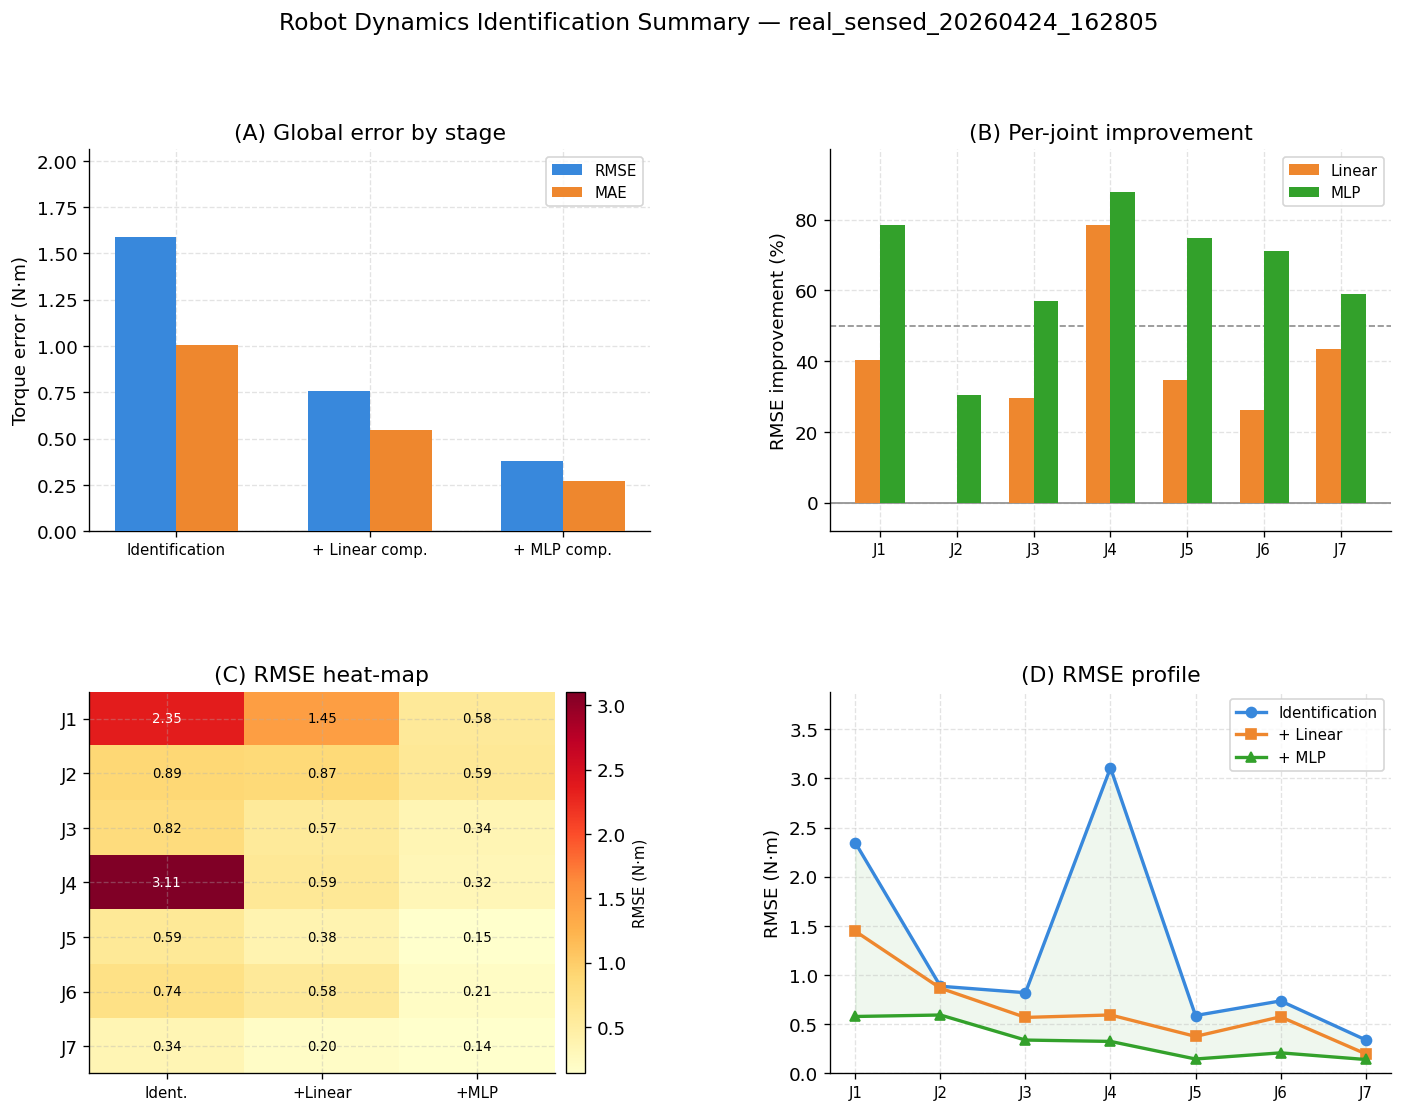

所有图表已生成


In [9]:
fig = plt.figure(figsize=(14, 10))
gs = GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.32)

ax_a = fig.add_subplot(gs[0, 0])
x, w = np.arange(len(STAGES)), 0.32
ax_a.bar(x - w/2, rmse_global, w, color=C_BLUE, label='RMSE', zorder=3)
ax_a.bar(x + w/2, mae_global, w, color=C_ORANGE, label='MAE', zorder=3)
ax_a.set_xticks(x)
ax_a.set_xticklabels(STAGES, fontsize=9)
ax_a.set_ylabel('Torque error (N·m)')
ax_a.set_title('(A) Global error by stage', fontweight='normal')
ax_a.legend(fontsize=9)
ax_a.set_ylim(0, max(rmse_global.max(), mae_global.max()) * 1.3)

ax_b = fig.add_subplot(gs[0, 1])
xj, wj = np.arange(N_JOINTS), 0.32
ax_b.bar(xj - wj/2, impr_linear, wj, color=C_ORANGE, label='Linear', zorder=3)
ax_b.bar(xj + wj/2, impr_mlp, wj, color=C_GREEN, label='MLP', zorder=3)
ax_b.axhline(0, color=C_GRAY, lw=1)
ax_b.axhline(50, color=C_GRAY, linestyle='--', lw=1)
ax_b.set_xticks(xj)
ax_b.set_xticklabels(JOINTS, fontsize=9)
ax_b.set_ylabel('RMSE improvement (%)')
ax_b.set_title('(B) Per-joint improvement', fontweight='normal')
ax_b.legend(fontsize=9)
ax_b.set_ylim(min(0, impr_linear.min(), impr_mlp.min()) - 8, max(55, impr_linear.max(), impr_mlp.max()) + 12)

ax_c = fig.add_subplot(gs[1, 0])
heatmap = np.vstack([rmse_ident, rmse_linear, rmse_mlp]).T
im = ax_c.imshow(heatmap, cmap='YlOrRd', aspect='auto')
fig.colorbar(im, ax=ax_c, pad=0.02).set_label('RMSE (N·m)', fontsize=9)
ax_c.set_xticks(range(len(STAGES)))
ax_c.set_xticklabels(['Ident.', '+Linear', '+MLP'], fontsize=9)
ax_c.set_yticks(range(N_JOINTS))
ax_c.set_yticklabels(JOINTS)
ax_c.set_title('(C) RMSE heat-map', fontweight='normal')
threshold = heatmap.max() * 0.55
for r in range(N_JOINTS):
    for c in range(len(STAGES)):
        v = heatmap[r, c]
        ax_c.text(c, r, f'{v:.2f}', ha='center', va='center', fontsize=8,
                  color='white' if v > threshold else 'black')

ax_d = fig.add_subplot(gs[1, 1])
ax_d.plot(xj, rmse_ident, 'o-', color=C_BLUE, lw=2, ms=6, label='Identification')
ax_d.plot(xj, rmse_linear, 's-', color=C_ORANGE, lw=2, ms=6, label='+ Linear')
ax_d.plot(xj, rmse_mlp, '^-', color=C_GREEN, lw=2, ms=6, label='+ MLP')
ax_d.fill_between(xj, rmse_mlp, rmse_ident, alpha=0.08, color=C_GREEN)
ax_d.set_xticks(xj)
ax_d.set_xticklabels(JOINTS, fontsize=9)
ax_d.set_ylabel('RMSE (N·m)')
ax_d.set_title('(D) RMSE profile', fontweight='normal')
ax_d.legend(fontsize=9)
ax_d.set_ylim(0, max(rmse_ident.max(), rmse_linear.max(), rmse_mlp.max()) * 1.25)

fig.suptitle(f'Robot Dynamics Identification Summary — {RESULT_STEM}', fontsize=14, fontweight='normal', y=0.995)
plt.savefig('fig8_summary_2x2.png', dpi=150, bbox_inches='tight')
plt.show()
print('所有图表已生成')


---
## Fig 9 — Raw 全量数据：各关节实测值 / 预测值 / 偏差

这组图直接针对 raw 全量时序展开：
- 左列：每个关节的 `measured torque` 与 `predicted torque`
- 右列：对应偏差 `error = measured - predicted`

说明：
- 数据来自 `datasets/real/normalized/*_normalized.csv`
- 预测使用当前最新 `theta_hat_*_latest.json` 回放
- 灰色竖虚线表示不同 raw 文件拼接边界


Built physically consistent regressor: shape (831467, 84)


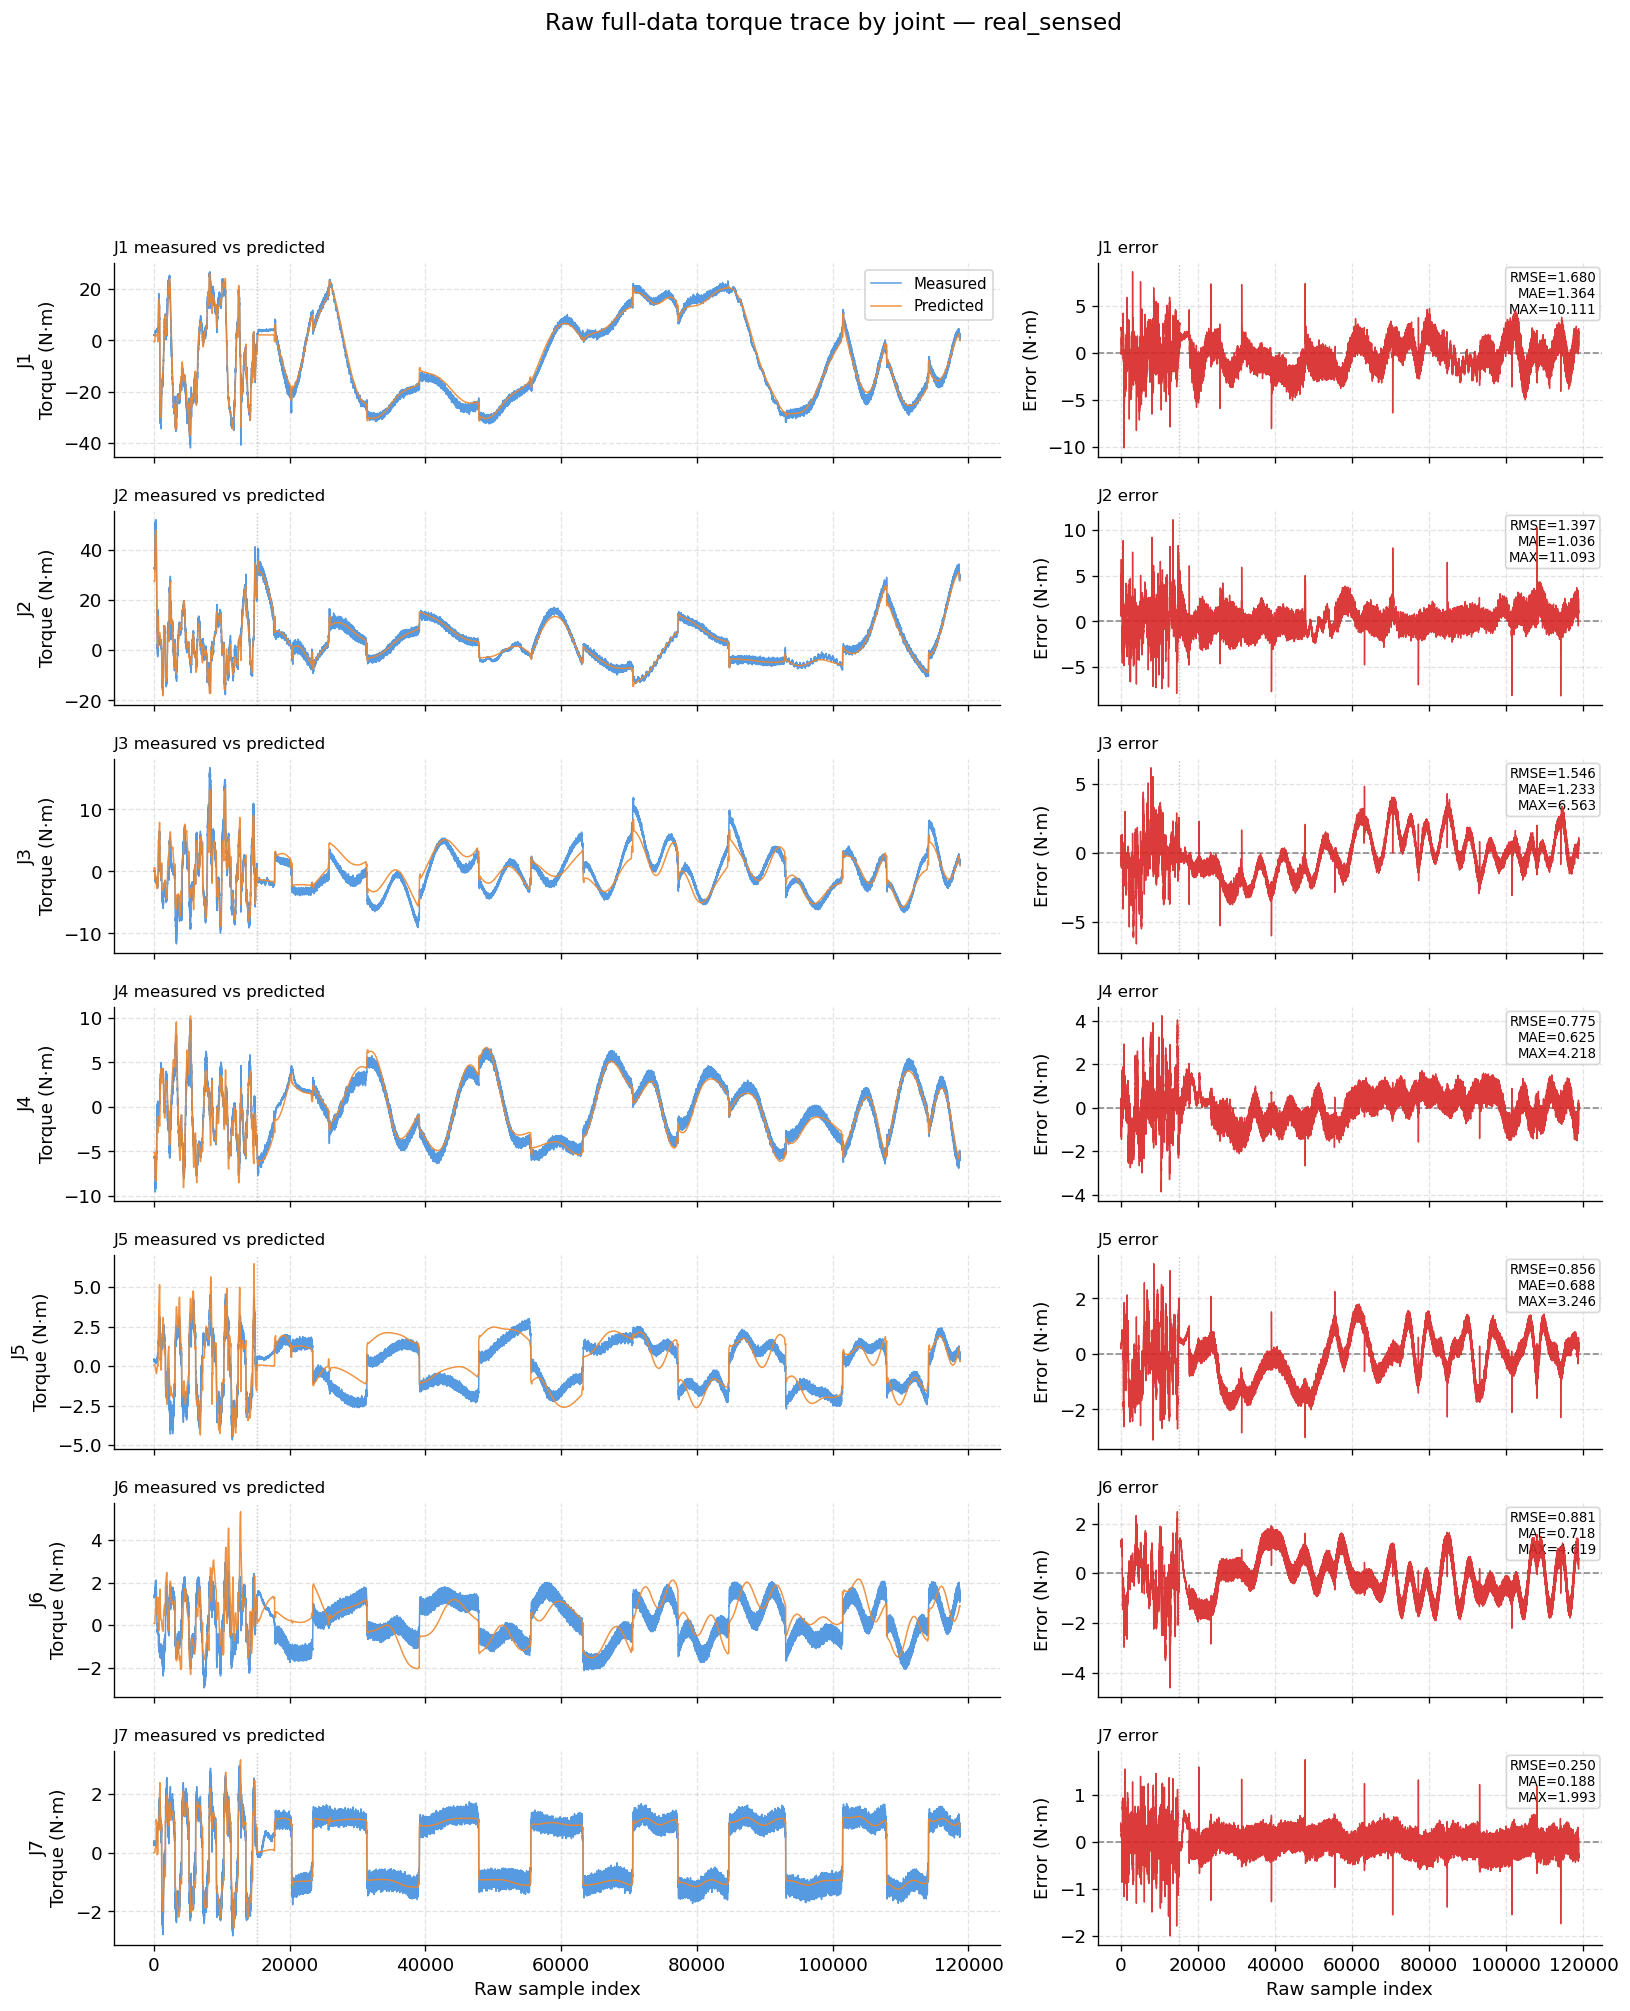

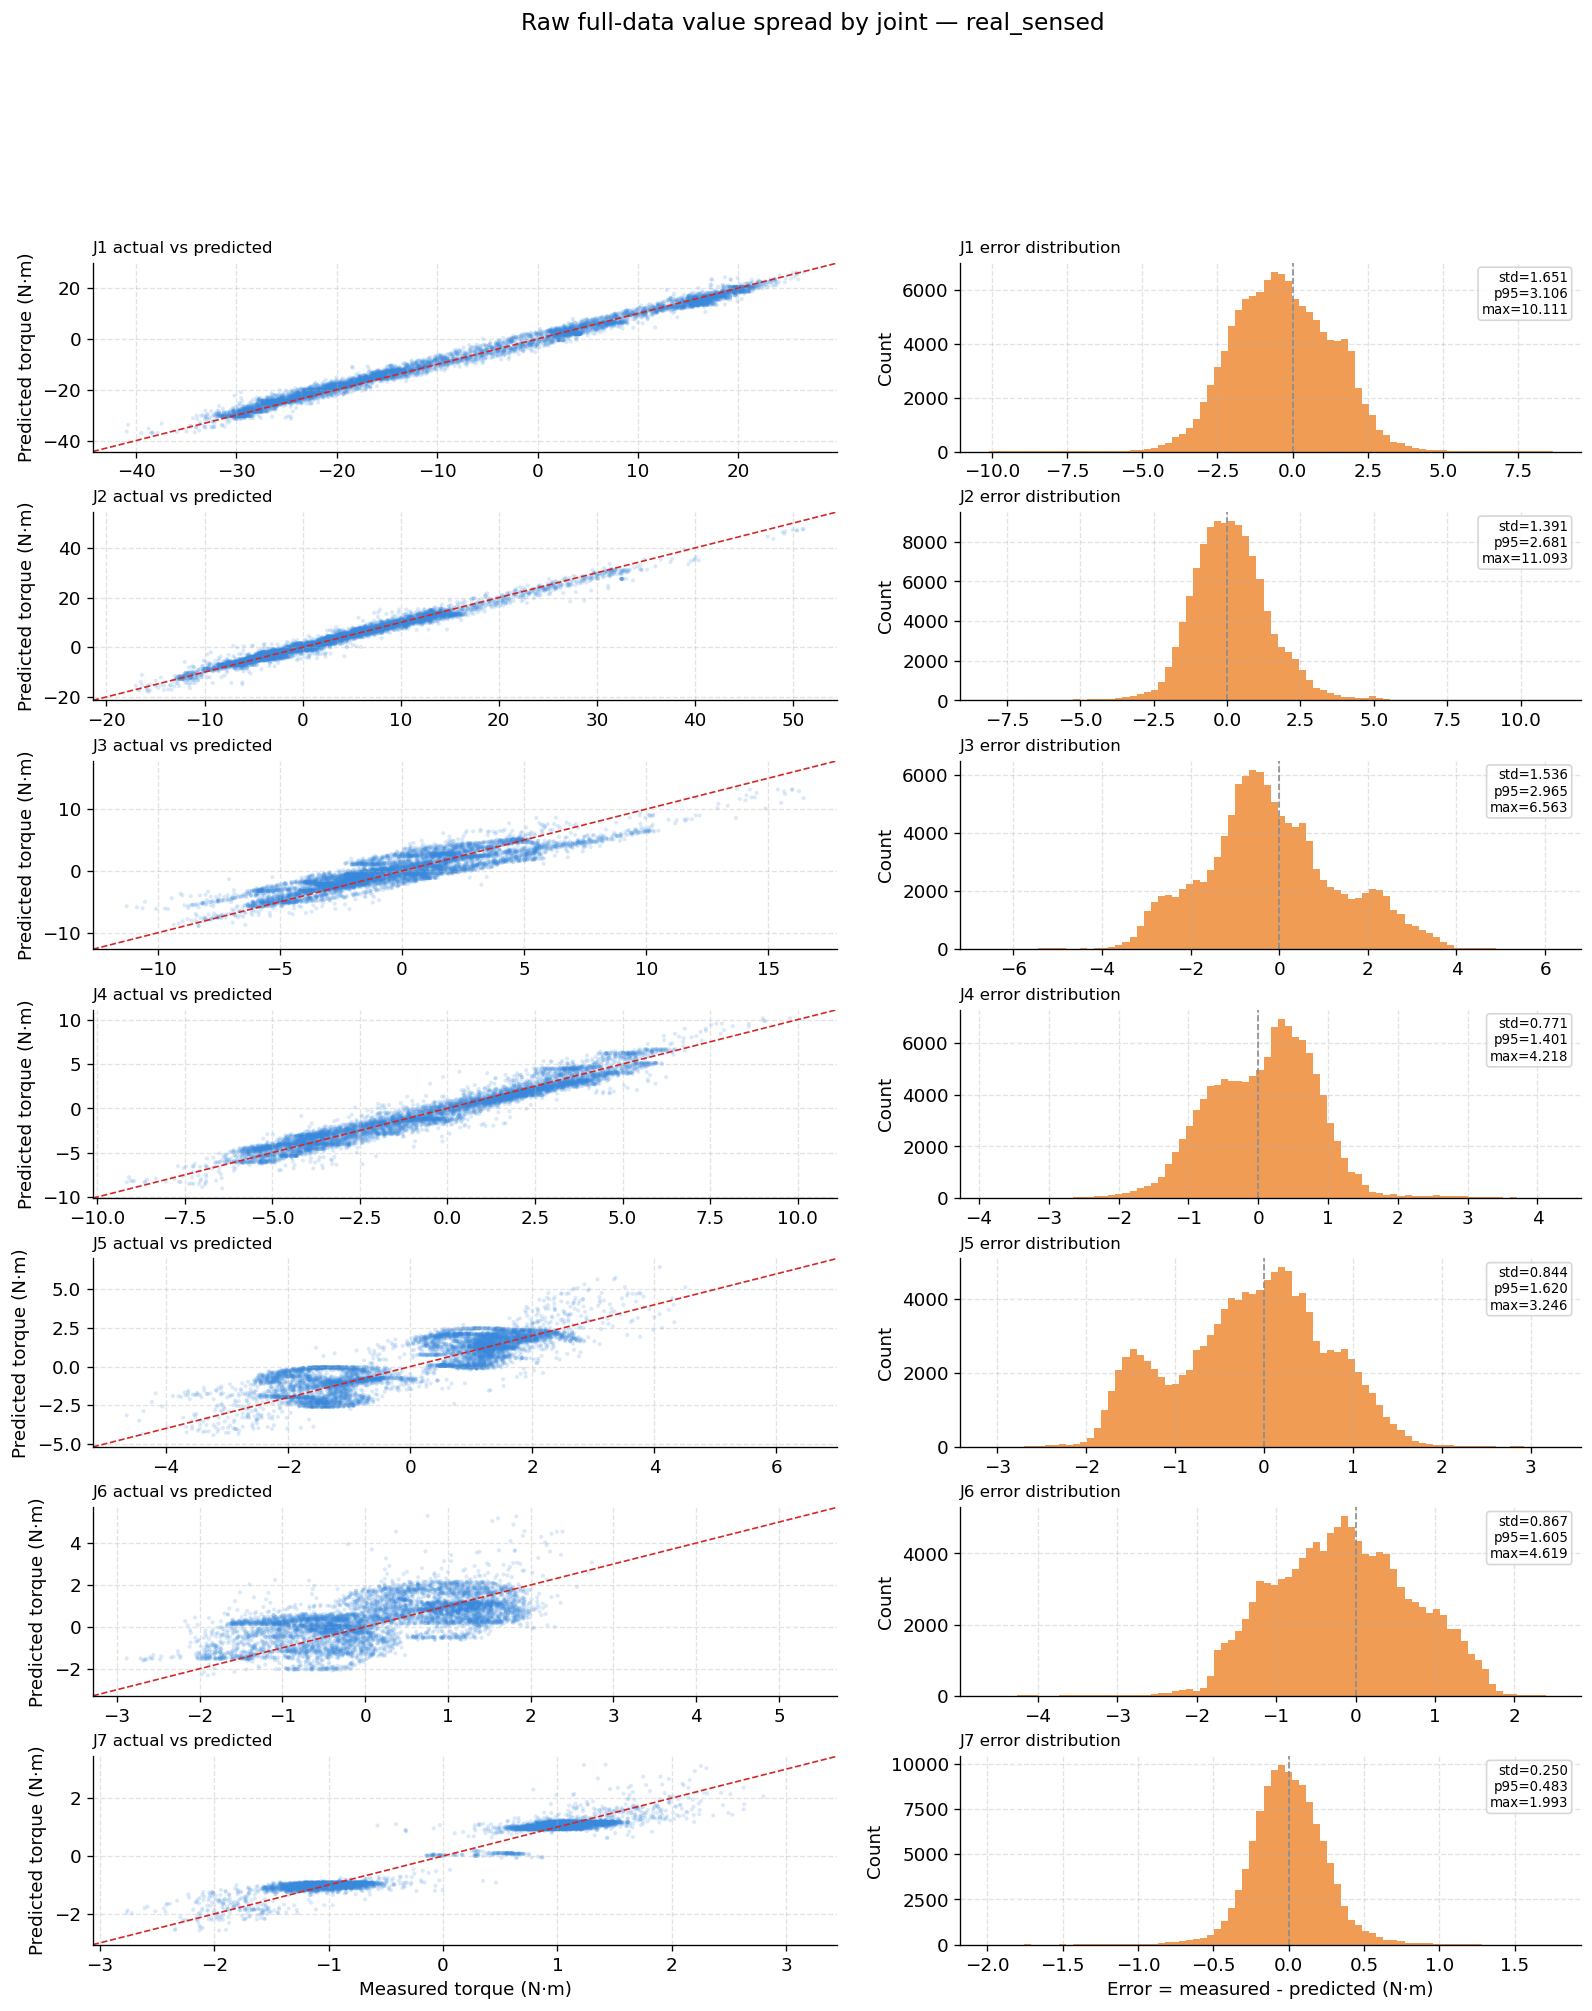

joint  measured_min  measured_max  predicted_min  predicted_max  error_mean  error_std    mae   rmse  p95_abs_error  max_abs_error
   J1       -42.074        26.841       -37.0321        26.2157     -0.3113     1.6513 1.3638 1.6804         3.1059        10.1111
   J2       -17.688        51.857       -18.1875        47.6467      0.1323     1.3906 1.0363 1.3968         2.6814        11.0934
   J3       -11.693        16.701        -8.9120        13.3247     -0.1705     1.5365 1.2328 1.5459         2.9653         6.5634
   J4        -9.558         9.932        -9.0733        10.2437      0.0776     0.7710 0.6250 0.7749         1.4012         4.2178
   J5        -4.659         4.577        -4.4362         6.4922     -0.1459     0.8438 0.6884 0.8564         1.6197         3.2459
   J6        -2.941         2.949        -2.3187         5.3223     -0.1568     0.8667 0.7177 0.8808         1.6052         4.6188
   J7        -2.832         2.975        -2.5744         3.1642     -0.0004     0.2

In [1]:
if 'RAW_AVAILABLE' not in globals():
    import importlib
    import plot_results_support as _plot_results_support
    _plot_results_support = importlib.reload(_plot_results_support)
    globals().update(_plot_results_support.load_plot_context(save_figures=False))

if not RAW_AVAILABLE:
    print(f'Raw visualization unavailable: {RAW_REASON}')
else:
    fig, axes = plt.subplots(
        N_JOINTS, 2,
        figsize=(16, max(2.6 * N_JOINTS, 14)),
        sharex=True,
        gridspec_kw={'width_ratios': [2.2, 1.25], 'hspace': 0.28, 'wspace': 0.14},
    )

    if N_JOINTS == 1:
        axes = np.array([axes])

    x = RAW_SAMPLE_INDEX
    segment_boundaries = [seg['end'] for seg in RAW_SEGMENT_RANGES[:-1]]

    for joint_idx in range(N_JOINTS):
        ax_left = axes[joint_idx, 0]
        ax_right = axes[joint_idx, 1]

        tau_meas = RAW_TAU_MEAS[:, joint_idx]
        tau_pred = RAW_TAU_PRED[:, joint_idx]
        tau_err = RAW_TAU_ERR[:, joint_idx]

        ax_left.plot(x, tau_meas, color=C_BLUE, lw=0.9, alpha=0.85, label='Measured', zorder=3)
        ax_left.plot(x, tau_pred, color=C_ORANGE, lw=0.9, alpha=0.9, label='Predicted', zorder=4)
        ax_left.set_ylabel(f'{JOINTS[joint_idx]}\nTorque (N·m)')
        ax_left.set_title(f'{JOINTS[joint_idx]} measured vs predicted', fontsize=10, fontweight='normal', loc='left')

        ax_right.plot(x, tau_err, color=C_RED, lw=0.85, alpha=0.9, zorder=4)
        ax_right.axhline(0.0, color=C_GRAY, lw=1.0, linestyle='--', zorder=2)
        ax_right.set_ylabel('Error (N·m)')
        ax_right.set_title(f'{JOINTS[joint_idx]} error', fontsize=10, fontweight='normal', loc='left')

        err_rmse = float(np.sqrt(np.mean(tau_err ** 2)))
        err_mae = float(np.mean(np.abs(tau_err)))
        err_max = float(np.max(np.abs(tau_err)))
        ax_right.text(
            0.99, 0.96,
            f'RMSE={err_rmse:.3f}\nMAE={err_mae:.3f}\nMAX={err_max:.3f}',
            transform=ax_right.transAxes,
            ha='right', va='top', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.25', facecolor='white', edgecolor='#D0D0D0', alpha=0.85),
        )

        for boundary in segment_boundaries:
            ax_left.axvline(boundary, color=C_GRAY, linestyle=':', lw=0.8, alpha=0.55, zorder=1)
            ax_right.axvline(boundary, color=C_GRAY, linestyle=':', lw=0.8, alpha=0.55, zorder=1)

        if joint_idx == 0:
            ax_left.legend(loc='upper right', fontsize=9)

    axes[-1, 0].set_xlabel('Raw sample index')
    axes[-1, 1].set_xlabel('Raw sample index')
    fig.suptitle(
        f'Raw full-data torque trace by joint — {RESULT_STEM}',
        fontsize=14, fontweight='normal', y=0.995,
    )
    plt.savefig('fig9_raw_joint_traces.png', dpi=150, bbox_inches='tight')
    plt.show()

    fig, axes = plt.subplots(
        N_JOINTS, 2,
        figsize=(16, max(2.6 * N_JOINTS, 14)),
        gridspec_kw={'width_ratios': [1.2, 1.0], 'hspace': 0.32, 'wspace': 0.18},
    )

    if N_JOINTS == 1:
        axes = np.array([axes])

    summary_rows = []

    for joint_idx in range(N_JOINTS):
        ax_scatter = axes[joint_idx, 0]
        ax_hist = axes[joint_idx, 1]

        tau_meas = RAW_TAU_MEAS[:, joint_idx]
        tau_pred = RAW_TAU_PRED[:, joint_idx]
        tau_err = RAW_TAU_ERR[:, joint_idx]

        err_mean = float(np.mean(tau_err))
        err_std = float(np.std(tau_err))
        err_mae = float(np.mean(np.abs(tau_err)))
        err_rmse = float(np.sqrt(np.mean(tau_err ** 2)))
        err_max = float(np.max(np.abs(tau_err)))
        p95_abs = float(np.percentile(np.abs(tau_err), 95))

        summary_rows.append({
            'joint': JOINTS[joint_idx],
            'measured_min': float(np.min(tau_meas)),
            'measured_max': float(np.max(tau_meas)),
            'predicted_min': float(np.min(tau_pred)),
            'predicted_max': float(np.max(tau_pred)),
            'error_mean': err_mean,
            'error_std': err_std,
            'mae': err_mae,
            'rmse': err_rmse,
            'p95_abs_error': p95_abs,
            'max_abs_error': err_max,
        })

        step = max(1, len(tau_meas) // 6000)
        meas_plot = tau_meas[::step]
        pred_plot = tau_pred[::step]

        min_val = float(min(meas_plot.min(), pred_plot.min()))
        max_val = float(max(meas_plot.max(), pred_plot.max()))
        lim_pad = 0.05 * max(1.0, max_val - min_val)

        ax_scatter.scatter(meas_plot, pred_plot, s=6, alpha=0.18, color=C_BLUE, edgecolors='none')
        ax_scatter.plot([min_val - lim_pad, max_val + lim_pad], [min_val - lim_pad, max_val + lim_pad], color=C_RED, linestyle='--', lw=1.0)
        ax_scatter.set_xlim(min_val - lim_pad, max_val + lim_pad)
        ax_scatter.set_ylim(min_val - lim_pad, max_val + lim_pad)
        ax_scatter.set_title(f'{JOINTS[joint_idx]} actual vs predicted', fontsize=10, fontweight='normal', loc='left')
        ax_scatter.set_ylabel('Predicted torque (N·m)')

        ax_hist.hist(tau_err, bins=80, color=C_ORANGE, alpha=0.82)
        ax_hist.axvline(0.0, color=C_GRAY, linestyle='--', lw=1.0)
        ax_hist.set_title(f'{JOINTS[joint_idx]} error distribution', fontsize=10, fontweight='normal', loc='left')
        ax_hist.set_ylabel('Count')
        ax_hist.text(
            0.98, 0.96,
            f'std={err_std:.3f}\np95={p95_abs:.3f}\nmax={err_max:.3f}',
            transform=ax_hist.transAxes,
            ha='right', va='top', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.25', facecolor='white', edgecolor='#D0D0D0', alpha=0.85),
        )

    axes[-1, 0].set_xlabel('Measured torque (N·m)')
    axes[-1, 1].set_xlabel('Error = measured - predicted (N·m)')
    fig.suptitle(
        f'Raw full-data value spread by joint — {RESULT_STEM}',
        fontsize=14, fontweight='normal', y=0.995,
    )
    plt.savefig('fig10_raw_joint_value_spread.png', dpi=150, bbox_inches='tight')
    plt.show()

    summary_df = pd.DataFrame(summary_rows)
    if 'display' in globals():
        display(summary_df.round(4))
    else:
        print(summary_df.round(4).to_string(index=False))

    print(f'Raw files merged: {len(RAW_SOURCE_FILES)}')
    print(f'Total raw samples: {len(RAW_SAMPLE_INDEX)}')
    for seg in RAW_SEGMENT_RANGES:
        print(f"  {seg['file']}: [{seg['start']}, {seg['end']})")
